In [270]:
import warnings
from pathlib import Path

import xarray as xr
import numpy as np

from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.materials import (
    compute_mat_intensities_commercial,
    compute_mat_intensities_residential,
)
from imagematerials.buildings.preprocessing.population import compute_population
from imagematerials.concepts import create_building_graph



from matplotlib import pyplot as plt

from imagematerials.buildings.preprocessing.population import compute_rur_urb_pop



In [271]:
base_directory = Path("..", "data", "raw")
scenario_sel = "SSP2_baseline"

database_directory = base_directory / "buildings" / "SSP2_CP"
image_directory = base_directory / "image" / scenario_sel

In [272]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)

In [273]:
# Rural/Urban floorspace [Time, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})

# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})

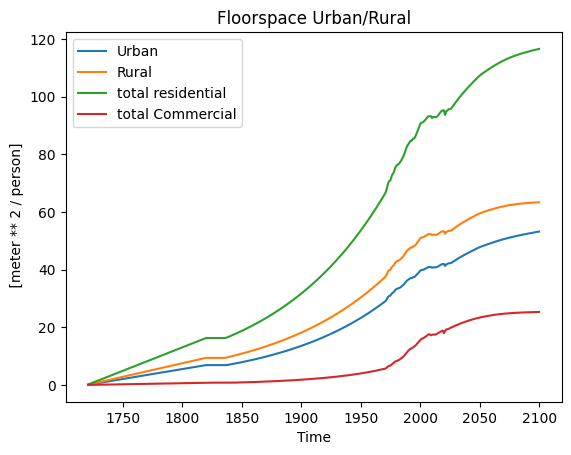

In [274]:
# Rural/Urban floorspace [Year, Region, Area]

floorspace_rururb.sel(Area="Urban", Region = '11').plot(label="Urban")
floorspace_rururb.sel(Area="Rural", Region = '11').plot(label="Rural")
floorspace_rururb.sel(Region = '11').sum(["Area"]).plot(label="total residential")
floorspace_commercial.sel(Region = '11').sum(["Type"]).plot(label="total Commercial")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [275]:
# Calculate population ("Total", "Rural", "Urban")
urban_pop_total, rural_pop_total = compute_rur_urb_pop(image_directory, base_directory)
population = compute_population(image_directory, base_directory)

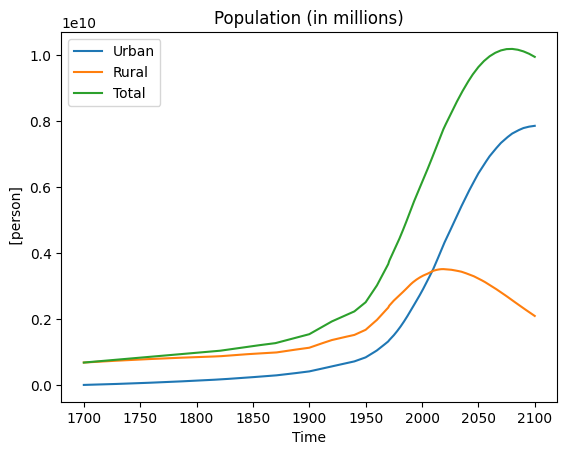

In [276]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [277]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)
print('average_m2_capita:', average_m2_capita.pint.units)
housing_type = compute_housing_type(database_directory)

average_m2_capita: meter ** 2 / person


In [278]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, 
                                                     average_m2_capita, 
                                                     housing_type, 
                                                     floorspace_rururb, {"test":None})

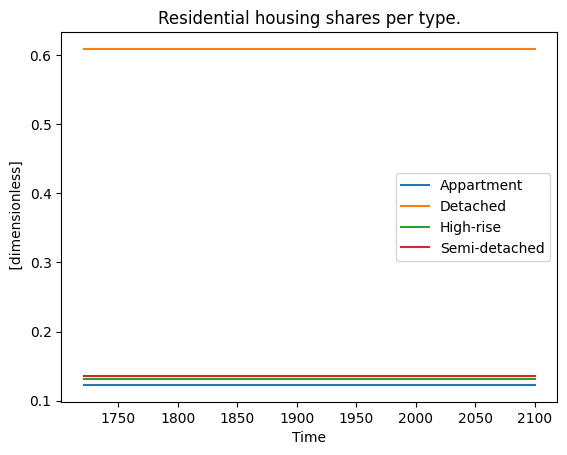

In [279]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

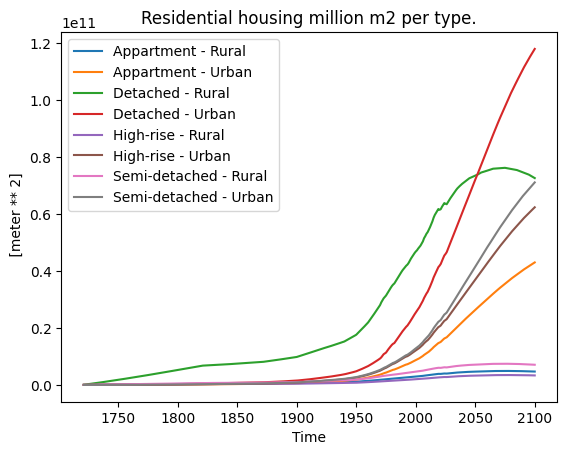

In [280]:


for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [281]:
floorspace_commercial_total = floorspace_commercial * population.sel({"Area": "Total"})

In [282]:
circular_economy_config = {"test": None}

floorspace_commercial_total = floorspace_commercial_total.drop_vars("Area")
floorspace = xr.concat((floorspace_residential, floorspace_commercial_total), dim="Type")

# Lifetime computations, see lifetimes.py

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes = compute_lifetimes(base_directory, floorspace_commercial.coords["Type"].values, circular_economy_config)

mat_intensities_comm = compute_mat_intensities_commercial(database_directory, circular_economy_config)
mat_intensities_res = compute_mat_intensities_residential(database_directory, circular_economy_config)
mat_intensities = xr.concat((mat_intensities_res, mat_intensities_comm), dim="Type")
knowledge_graph = create_building_graph()
mat_intensities = knowledge_graph.rebroadcast_xarray(
                        mat_intensities, floorspace.coords["Type"].values)

#TODO remove this quick fix
region_coords = np.sort(floorspace.coords["Region"].values.astype(int)).astype(str)

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\indexing.py:1720: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [283]:
floorspace

<xarray.DataArray (Time: 380, Region: 26, Type: 12)> Size: 948kB
<Quantity([[[1.94046845e+04 2.33900918e+03 3.18723684e+05 ... 5.42262826e+02
   1.48782863e+03 3.09874480e+04]
  [5.74165730e+04 9.96550594e+03 3.41048739e+06 ... 5.72309835e+03
   1.49163953e+04 3.22370278e+05]
  [4.66094483e+04 4.71300534e+03 7.65564374e+05 ... 1.28569549e+03
   3.52761515e+03 7.34706867e+04]
  ...
  [1.08913087e+04 2.83591264e+03 3.38408519e+05 ... 4.29782460e+02
   1.17921166e+03 2.45597909e+04]
  [2.27727454e+05 3.87398324e+03 2.30547359e+06 ... 4.11580505e+03
   1.12927021e+04 2.35196456e+05]
  [4.31836499e+04 8.58216442e+02 7.09295326e+05 ... 1.14686957e+03
   3.14671281e+03 6.55375207e+04]]

 [[3.88485641e+04 4.92032016e+03 6.38091154e+05 ... 1.08884957e+03
   2.98752097e+03 6.22219849e+04]
  [1.14958863e+05 2.09633550e+04 6.82844225e+06 ... 1.14918318e+04
   2.99517314e+04 6.47311086e+05]
  [9.33741162e+04 9.91423863e+03 1.53367824e+06 ... 2.58164291e+03
   7.08335894e+03 1.47527217e+05]
...
  [3.93390478e+06 4.39478286e+08 1.22232042e+08 ... 3.70953137e+08
   1.38490611e+08 4.60542962e+08]
  [6.67764214e+08 2.33342775e+09 6.76033009e+09 ... 5.33336248e+09
   1.76950265e+09 7.75814641e+09]
  [3.50673850e+08 1.96507795e+09 5.75984947e+09 ... 1.47617412e+09
   5.81684532e+08 3.81050074e+09]]

 [[5.54685341e+06 3.48485091e+08 9.11075653e+07 ... 3.60673014e+08
   1.36833464e+08 4.48249618e+08]
  [1.52538393e+07 1.62140969e+09 9.06062897e+08 ... 3.29309606e+09
   1.23888950e+09 4.08955288e+09]
  [2.36355959e+07 1.00192200e+09 3.88216785e+08 ... 1.00490598e+09
   3.34722471e+08 1.39100550e+09]
  ...
  [3.86591659e+06 4.39568119e+08 1.20119551e+08 ... 3.70780855e+08
   1.38582142e+08 4.60335959e+08]
  [6.64546015e+08 2.35518112e+09 6.72774959e+09 ... 5.42785361e+09
   1.80135650e+09 7.79513732e+09]
  [3.52688855e+08 2.00299410e+09 5.79294610e+09 ... 1.56196868e+09
   6.05258221e+08 3.88223438e+09]]], 'meter ** 2')>
Coordinates:
  * Time     (Time) int64 3kB 1721 1722 1723 1724 1725 ... 2097 2098 2099 2100
  * Region   (Region) <U2 208B '1' '2' '3' '4' '5' ... '22' '23' '24' '25' '26'
  * Type     (Type) <U21 1kB 'Appartment - Rural' ... 'Govt+'

In [284]:
import pandas as pd
from imagematerials.read_mym import read_mym_df

from imagematerials.buildings.constants import (
    END_YEAR,
    FLAG_ALPHA,
    FLAG_EXPDEC,
    GOMPERTZ_EXPDEC,
    HIST_YEAR,
    INFLATION,
    REGIONS,
    REGIONS_RANGE,
    START_YEAR,
    YEARS,
)

floorspace: pd.DataFrame = read_mym_df(image_directory.joinpath("EnergyServices",
                                                                "res_FloorSpace.out"))
floorspace_urban_rural_tot = floorspace[['time','DIM_1',2,3, 4,5,6,7,8,9,10,11,12,13]].rename(columns={"DIM_1": "Region", "time":"Time", 
                                                                 2:'Urban',
                                                                 3:'Rural',
                                                                 4:'Urban Q1',
                                                                 5:'Urban Q2',
                                                                 6:'Urban Q3',
                                                                 7:'Urban Q4',
                                                                 8:'Urban Q5',
                                                                 9:'Rural Q1',
                                                                 10:'Rural Q2',
                                                                 11:'Rural Q3',
                                                                 12:'Rural Q4',
                                                                 13:'Rural Q5'})
                                                                                

In [285]:
pop_q: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "pop_q.out"))
pop_q = pop_q.rename(columns={"time": "Time", "DIM_1": "Region"})
value_cols = [c for c in pop_q.columns if c not in ["Time", "Region"]]

pop_q_xr = (
    pop_q
    .set_index(["Time", "Region"])[value_cols]
    .rename_axis(columns="Area")
    .stack()
    .to_xarray()
    .transpose("Time", "Region", "Area")
)

area_labels = {
    1: "Total",
    2: "Urban",
    3: "Rural",
    4: "Urban Q1",
    5: "Urban Q2",
    6: "Urban Q3",
    7: "Urban Q4",
    8: "Urban Q5",
    9: "Rural Q1",
    10: "Rural Q2",
    11: "Rural Q3",
    12: "Rural Q4",
    13: "Rural Q5",
}
pop_q_xr = pop_q_xr.assign_coords(
    Area=[area_labels.get(a, a) for a in pop_q_xr.coords["Area"].values]
)
import prism
# remove region 27 (global)
pop_q_xr = pop_q_xr.sel(Region=REGIONS_RANGE)
prism.Q_(pop_q_xr, "people")


Magnitude,[[[21888680.0 16557780.0 5330900.0 ... 1066180.0 1066180.0 1066180.0] [202907900.0 149365800.0 53542140.0 ... 10708430.0 10708430.0 10708430.0] [51897680.0 31018510.0 20879160.0 ... 4175833.0 4175833.0 4175833.0] ... [17348360.0 13918330.0 3430035.0 ... 686007.0 686007.0 686007.0] [166136300.0 25496510.0 140639800.0 ... 28127950.0 28127950.0 28127950.0] [46293900.0 5648327.0 40645580.0 ... 8129115.0 8129115.0 8129115.0]] [[22222220.0 16808180.0 5414045.0 ... 1082809.0 1082809.0 1082809.0] [205238400.0 151102300.0 54136150.0 ... 10827230.0 10827230.0 10827230.0] [53543440.0 32402450.0 21140980.0 ... 4228197.0 4228197.0 4228197.0] ... [17742280.0 14263580.0 3478703.0 ... 695740.5 695740.5 695740.5] [169559800.0 26693940.0 142865900.0 ... 28573170.0 28573170.0 28573170.0] [47735380.0 6130323.0 41605060.0 ... 8321012.0 8321012.0 8321012.0]] [[22502030.0 17017880.0 5484150.0 ... 1096830.0 1096830.0 1096830.0] [207314800.0 152652100.0 54662670.0 ... 10932530.0 10932530.0 10932530.0] [55228200.0 33834900.0 21393310.0 ... 4278661.0 4278661.0 4278661.0] ... [18050490.0 14541080.0 3509408.0 ... 701881.5 701881.5 701881.5] [173976200.0 28078730.0 145897400.0 ... 29179490.0 29179490.0 29179490.0] [49286110.0 6645534.0 42640570.0 ... 8528114.0 8528114.0 8528114.0]] ... [[44605880.0 42914530.0 1691357.0 ... 338271.3 338271.3 338271.3] [406560700.0 392705100.0 13855580.0 ... 2771116.0 2771116.0 2771116.0] [146917800.0 138694500.0 8223234.0 ... 1644647.0 1644647.0 1644647.0] ... [45817380.0 43916330.0 1901052.0 ... 380210.5 380210.5 380210.5] [832416600.0 580497900.0 251918600.0 ... 50383720.0 50383720.0 50383720.0] [519532800.0 371286800.0 148246100.0 ... 29649220.0 29649220.0 29649220.0]] [[44544340.0 42888480.0 1655861.0 ... 331172.3 331172.3 331172.3] [406384000.0 392828200.0 13555800.0 ... 2711159.0 2711159.0 2711159.0] [146582000.0 138504900.0 8077136.0 ... 1615427.0 1615427.0 1615427.0] ... [45789800.0 43917600.0 1872193.0 ... 374438.5 374438.5 374438.5] [832121500.0 582683500.0 249438000.0 ... 49887600.0 49887600.0 49887600.0] [520221200.0 373147900.0 147073400.0 ... 29414680.0 29414680.0 29414680.0]] [[44482800.0 42862340.0 1620458.0 ... 324091.5 324091.5 324091.5] [406207300.0 392951000.0 13256270.0 ... 2651253.0 2651253.0 2651253.0] [146246300.0 138314700.0 7931622.0 ... 1586324.0 1586324.0 1586324.0] ... [45762210.0 43918840.0 1843366.0 ... 368673.3 368673.3 368673.3] [831826400.0 584867300.0 246959100.0 ... 49391820.0 49391820.0 49391820.0] [520909700.0 375012600.0 145897100.0 ... 29179420.0 29179420.0 29179420.0]]]
Units,person


In [286]:
historic_population = pd.read_csv(base_directory / 'buildings' / 'standard_data'
                               / 'historic_population.csv', index_col=0, header = 0)

historic_population = historic_population.loc[:1971] / 1000 # unit conversion
historic_population

historic_population = historic_population.reindex(range(historic_population.index.min(),
                                            historic_population.index.max() + 1)
                                    ).interpolate(method="linear")


In [287]:
# 1) Total population by region (historic + IMAGE), then annual interpolation
historic_population.columns = [str(c) for c in historic_population.columns]
historic_population.index = historic_population.index.astype(int)
historic_population.index.name = "Time"

historic_total_xr = xr.DataArray(
    historic_population.values,
    dims=("Time", "Region"),
    coords={
        "Time": historic_population.index.to_numpy(),
        "Region": historic_population.columns.to_numpy(),
    },
)

image_total_xr = pop_q_xr.sel(Area="Total")
image_total_xr = image_total_xr.assign_coords(
    Region=[str(r) for r in image_total_xr.coords["Region"].values]
)

time_all = np.arange(
    int(min(historic_total_xr.coords["Time"].min(), image_total_xr.coords["Time"].min())),
    int(max(historic_total_xr.coords["Time"].max(), image_total_xr.coords["Time"].max())) + 1,
)
regions_all = [str(r) for r in REGIONS_RANGE]

historic_total_xr = historic_total_xr.reindex(Time=time_all, Region=regions_all)
image_total_xr = image_total_xr.reindex(Region=regions_all).interp(
    Time=time_all, kwargs={"fill_value": "extrapolate"}
)

# Prefer historic where available, use IMAGE total otherwise
total_population_xr = historic_total_xr.combine_first(image_total_xr)
total_population_xr = total_population_xr.interpolate_na(
    dim="Time", method="linear"
)
total_population_xr = total_population_xr.clip(min=0)

# 2) Urban/Rural shares from IMAGE and annual interpolation per region
ur_share = pop_q_xr.sel(Area=["Urban", "Rural"]) / pop_q_xr.sel(Area="Total")
ur_share = ur_share.assign_coords(Region=[str(r) for r in ur_share.coords["Region"].values])
ur_share = ur_share.reindex(Region=regions_all).interp(
    Time=time_all, kwargs={"fill_value": "extrapolate"}
)
ur_share = ur_share.clip(min=0)
ur_share_sum = ur_share.sum(dim="Area")
ur_share = xr.where(ur_share_sum > 0, ur_share / ur_share_sum, 0)

urban_rural_population_xr = ur_share * total_population_xr

# 3) Quintile shares within Urban and within Rural, then annual interpolation
urban_q_areas = ["Urban Q1", "Urban Q2", "Urban Q3", "Urban Q4", "Urban Q5"]
rural_q_areas = ["Rural Q1", "Rural Q2", "Rural Q3", "Rural Q4", "Rural Q5"]

urban_q_share = pop_q_xr.sel(Area=urban_q_areas) / pop_q_xr.sel(Area="Urban")
urban_q_share = urban_q_share.assign_coords(
    Region=[str(r) for r in urban_q_share.coords["Region"].values]
)
urban_q_share = urban_q_share.reindex(Region=regions_all).interp(
    Time=time_all, kwargs={"fill_value": "extrapolate"}
)
urban_q_share = urban_q_share.clip(min=0)
urban_q_sum = urban_q_share.sum(dim="Area")
urban_q_share = xr.where(urban_q_sum > 0, urban_q_share / urban_q_sum, 0)

rural_q_share = pop_q_xr.sel(Area=rural_q_areas) / pop_q_xr.sel(Area="Rural")
rural_q_share = rural_q_share.assign_coords(
    Region=[str(r) for r in rural_q_share.coords["Region"].values]
)
rural_q_share = rural_q_share.reindex(Region=regions_all).interp(
    Time=time_all, kwargs={"fill_value": "extrapolate"}
)
rural_q_share = rural_q_share.clip(min=0)
rural_q_sum = rural_q_share.sum(dim="Area")
rural_q_share = xr.where(rural_q_sum > 0, rural_q_share / rural_q_sum, 0)

urban_quintiles_population_xr = urban_q_share * urban_rural_population_xr.sel(Area="Urban")
rural_quintiles_population_xr = rural_q_share * urban_rural_population_xr.sel(Area="Rural")

# 4) Final result: Total + Urban/Rural + all quintiles
population_split_xr = xr.concat(
    [
        total_population_xr.expand_dims(Area=["Total"]),
        urban_rural_population_xr,
        urban_quintiles_population_xr,
        rural_quintiles_population_xr,
    ],
    dim="Area",
)
population_split_xr = population_split_xr.transpose("Time", "Region", "Area")
population_split_xr = population_split_xr.clip(min=0)
prism.Q_(population_split_xr, "people")

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Magnitude,[[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] ... [[44605880.0 42914523.26542458 1691356.734575416 ... 338271.34691508324 338271.34691508324 338271.34691508324] [406560700.0 392705119.3184004 13855580.681599606 ... 2771116.1363199214 2771116.1363199214 2771116.1363199214] [146917800.0 138694562.3058684 8223237.6941316025 ... 1644647.5388263206 1644647.5388263206 1644647.5388263206] ... [45817380.0 43916328.08298388 1901051.917016123 ... 380210.38340322464 380210.38340322464 380210.38340322464] [832416600.0 580497969.736472 251918630.26352793 ... 50383726.052705586 50383726.052705586 50383726.052705586] [519532800.0 371286728.534497 148246071.46550295 ... 29649214.29310059 29649214.29310059 29649214.29310059]] [[44544340.0 42888479.037173316 1655860.9628266806 ... 331172.1925653361 331172.1925653361 331172.1925653361] [406384000.0 392828200.0 13555800.000000002 ... 2711160.0 2711160.0 2711160.0] [146582000.0 138504865.9837144 8077134.016285597 ... 1615426.8032571194 1615426.8032571194 1615426.8032571194] ... [45789800.0 43917606.71379319 1872193.2862068191 ... 374438.65724136384 374438.65724136384 374438.65724136384] [832121500.0 582683500.0 249438000.0 ... 49887600.0 49887600.0 49887600.0] [520221200.0 373147828.27131456 147073371.7286855 ... 29414674.3457371 29414674.3457371 29414674.3457371]] [[44482800.0 42862341.92714226 1620458.072857737 ... 324091.6145715474 324091.6145715474 324091.6145715474] [406207300.0 392951029.02097243 13256270.97902753 ... 2651254.1958055063 2651254.1958055063 2651254.1958055063] [146246300.0 138314679.1931629 7931620.806837112 ... 1586324.1613674222 1586324.1613674222 1586324.1613674222] ... [45762210.0 43918843.83887438 1843366.1611256239 ... 368673.2322251247 368673.2322251247 368673.2322251247] [831826400.0 584867300.0 246959100.0 ... 49391820.0 49391820.0 49391820.0] [520909700.0 375012600.0 145897100.0 ... 29179420.0 29179420.0 29179420.0]]]
Units,person


In [288]:
floorspace_xr = (
    floorspace_urban_rural_tot
    .set_index(["Time", "Region"])[["Urban", "Rural", 
                                    "Urban Q1", "Urban Q2", "Urban Q3", "Urban Q4", "Urban Q5",
                                   "Rural Q1", "Rural Q2", "Rural Q3", "Rural Q4", "Rural Q5"]]
    .rename_axis(columns="Type")
    .stack()
    .to_xarray()
    .transpose("Time", "Region", "Type")
)
floorspace_xr

# remove region 27 (global)
floorspace_xr = floorspace_xr.sel(Region=REGIONS_RANGE)
prism.Q_(floorspace_xr, "m^2/person")


Magnitude,[[[24.24231 31.04345 17.89082 ... 31.04345 35.11015 39.17684] [29.21335 37.52604 21.55945 ... 37.52604 42.44195 47.35786] [24.43794 31.93941 18.0352 ... 31.93941 36.12347 40.30754] ... [42.74829 54.29291 31.54823 ... 54.29291 61.40528 68.51765] [7.783268 10.66323 5.744051 ... 10.66323 12.06012 13.457] [12.54951 17.25392 9.26154 ... 17.25392 19.51418 21.77444]] [[25.36117 32.47667 18.71655 ... 32.47667 36.73111 40.98555] [31.13939 39.99953 22.98087 ... 39.99953 45.23947 50.4794] [24.83137 32.42654 18.32555 ... 32.42654 36.67442 40.92229] ... [42.7603 54.29291 31.5571 ... 54.29291 61.40528 68.51765] [7.783268 10.66323 5.744051 ... 10.66323 12.06012 13.457] [12.5906 17.29787 9.291863 ... 17.29787 19.5639 21.82992]] [[26.18913 33.53738 19.32757 ... 33.53738 37.93077 42.32417] [32.96421 42.34294 24.32759 ... 42.34294 47.88987 53.43679] [25.23662 32.92804 18.62463 ... 32.92804 37.24162 41.55518] ... [43.16423 54.78401 31.8552 ... 54.78401 61.96072 69.13741] [7.672579 10.50232 5.662363 ... 10.50232 11.87813 13.25393] [12.5906 17.29787 9.291863 ... 17.29787 19.5639 21.82992]] ... [[60.2889 67.54778 44.49321 ... 67.54778 76.39655 85.2453] [64.78445 71.3553 47.81092 ... 71.3553 80.70285 90.05038] [49.67476 58.32604 36.65997 ... 58.32604 65.96676 73.60746] ... [62.6559 71.08104 46.24005 ... 71.08104 80.39266 89.70427] [27.46282 35.46783 20.26756 ... 35.46783 40.11412 44.76041] [35.78815 46.11256 26.41166 ... 46.11256 52.15331 58.19405]] [[60.30195 67.35939 44.50284 ... 67.35939 76.18347 85.00755] [64.79805 71.10934 47.82096 ... 71.10934 80.42467 89.73999] [49.81903 58.40047 36.76644 ... 58.40047 66.05093 73.70139] ... [62.66694 70.94904 46.2482 ... 70.94904 80.24336 89.53768] [27.6205 35.65796 20.38393 ... 35.65796 40.32915 45.00034] [36.32191 46.78327 26.80557 ... 46.78327 52.91188 59.04048]] [[60.31501 67.16294 44.51247 ... 67.16294 75.96129 84.75963] [64.81165 70.85214 47.831 ... 70.85214 80.13377 89.4154] [49.9615 58.46919 36.87159 ... 58.46919 66.12865 73.78812] ... [62.67798 70.81293 46.25635 ... 70.81293 80.08943 89.36592] [27.7739 35.84231 20.49714 ... 35.84231 40.53765 45.23299] [36.83865 47.43145 27.18693 ... 47.43145 53.64497 59.85849]]]
Units,meter2/person


In [301]:
# commercial floorspace
from imagematerials.buildings.preprocessing.floorspace import compute_commercial_floor_m2_cap, compute_commercial_floor_m2_cap_sum, get_gompertz, get_service_value_added

gompertz = get_gompertz(base_directory)
service_value_added = get_service_value_added(image_directory)
commercial_m2_cap_sum = compute_commercial_floor_m2_cap_sum(gompertz, service_value_added)

commercial_m2_cap_df, minimum_comm = compute_commercial_floor_m2_cap(
        gompertz, commercial_m2_cap_sum, service_value_added)

minimum_comm = prism.Q_(minimum_comm, "m^2/person")

# Convert to xarray with Area dimension for commercial building types (Office, Retail+, Hotels+, Govt+)
commercial_m2_cap = (
    commercial_m2_cap_df
    .reset_index()
    .set_index(["Time", "Region"])
    .rename_axis(columns="Type")
    .stack()
    .to_xarray()
    .transpose("Time", "Region", "Type")
)
commercial_m2_cap = commercial_m2_cap.sel(Region=REGIONS_RANGE)
prism.Q_(commercial_m2_cap, "m^2/person")

C:\Coding\image-materials\imagematerials\buildings\preprocessing\floorspace.py:263: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
C:\Coding\image-materials\imagematerials

Magnitude,[[[0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] ... [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0]] [[5.162519639381394 0.5695782687879283 0.9799928090094342 1.0172585411973132] [6.260297509899814 0.8104841327012133 1.5456000085240102 1.7577990411777655] [2.6526484417445517 0.19752628118847773 0.22014540446529363 0.1866642993498816] ... [4.124914681751523 0.3908409218844191 0.5856629570866844 0.5598729998628907] [1.0508424388107154 0.05313661835653571 0.030446094864539936 0.021943258421537427] [1.1394837235158728 0.05937948259381425 0.036123219294912086 0.026328524356390354]] [[5.351873332323377 0.6068538462446877 1.065994732284103 1.1235909719113142] [6.430931046383938 0.8540460646818673 1.6487729944073592 1.9033668548383589] [2.7859321862348345 0.2125178508097333 0.24500081550829544 0.2101207736116333] ... [4.120735011560407 0.3901993418184374 0.5843211505433722 0.5584058062566812] [1.0301432513586604 0.0517103354053664 0.02919477502906425 0.020984923568405072] [1.1390707195440857 0.05934989243247568 0.03609556312328429 0.026307019971125136]] ... [[10.075737085566415 3.0725794438287073 4.318512564151302 8.10829455690089] [10.065818709152989 3.045024337870925 4.328867078911852 8.106161580158906] [9.46938908132093 2.2504075197306017 4.104904289284045 6.766912413141852] ... [10.056144686821636 3.020504361127879 4.336857249515167 8.099962818482327] [9.272298118091665 2.086214561367735 3.9423466465050745 6.286927898521068] [7.190859003154912 1.0741600169135817 2.161731139426101 2.6771733800140183]] [[10.076342333144536 3.074372048194983 4.317786910210852 8.108231653131611] [10.066753547110102 3.047500248191251 4.327997168310016 8.106574609667634] [9.490707257183699 2.2697055877462295 4.1214497920290585 6.819839778106113] ... [10.057765324147875 3.024486708198512 4.335635744947624 8.101219434513487] [9.32333367967654 2.126495524908914 3.98582205661892 6.409355464947768] [7.3247687820232805 1.1181482413040427 2.2613269161304044 2.837588763738728]] [[10.076920024513072 3.0760982638148975 4.317082027096154 8.108145492194021] [10.06764989329949 3.049894709613035 4.327144672154472 8.106934720056564] [9.511389364918903 2.2887585599149847 4.1372544989713615 6.871325845576907] ... [10.059303502494469 3.028309643860327 4.334435596842509 8.102337172919476] [9.371110756075089 2.165543801241655 4.025740998395519 6.525224019295082] [7.452797252652747 1.1619254186010737 2.3591207054804437 2.9985402006519823]]]
Units,meter2/person


C:\Users\Arp00003\AppData\Local\Temp\ipykernel_27132\2576032841.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  floorspace_all = xr.concat([floorspace_xr, commercial_m2_cap], dim="Type")


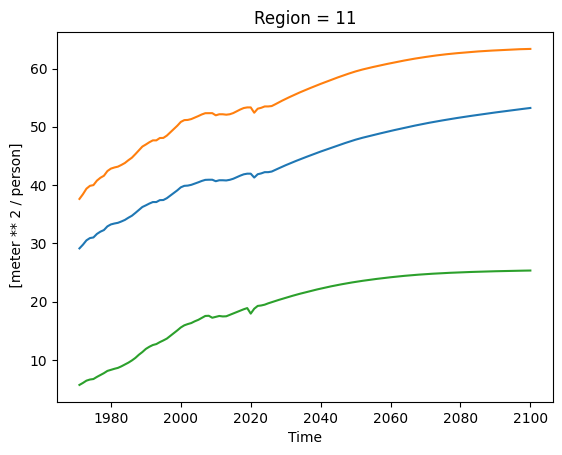

In [303]:
# Join commercial_m2_cap and floorspace_xr along Area dimension
floorspace_all = xr.concat([floorspace_xr, commercial_m2_cap], dim="Type")
floorspace_all.sel(Type="Urban").sel(Region = 11).loc[1971:].plot(label="Urban")
floorspace_all.sel(Type="Rural").sel(Region = 11).loc[1971:].plot(label="Rural")
floorspace_all.sel(Type=['Govt+', 'Hotels+', 'Office', 'Retail+']).sum("Type").sel(Region = 11).loc[1971:].plot(label="Hotels+")

In [304]:
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_all,
                                                          minimum_comm)

AlignmentError: cannot align objects with join='exact' where index/labels/sizes are not equal along these coordinates (dimensions): 'Type' ('Type',)